# Evaluation of trained models

## 1. Load saved data of model coarse tuning results

In [2]:
#%pip install pandas
#%pip install -U scikit-learn
import os
import pickle
import pandas as pd

# Directory containing your pickle files
results_dir = '..\\results\\results_per_model'
add_results_dir = '..\\results\\results_per_model\\additional_results'
# List to collect all rows from all pickle files
all_rows = []

# Iterate through all .pkl files in the directory
for filename in os.listdir(results_dir):
    if "robbert" in filename or "qwen" in filename or "mpnet" in filename:
        if filename.endswith('.pkl'):
            filepath = os.path.join(results_dir, filename)
            
            with open(filepath, 'rb') as f:
                model_results = pickle.load(f)

            # Flatten the dictionary into a list of records
            for (name, combination), metrics in model_results.items():
                row = {
                    "model_name": name,
                    "combination": combination,
                    **metrics
                }
                all_rows.append(row)



# Create a DataFrame
df = pd.DataFrame(all_rows)

# Drop duplicate rows
df = df.drop_duplicates()

# Optionally, reset index
df.reset_index(drop=True, inplace=True)

len(df)

336

## 2. Visualize trends of parameters for all models

In [3]:
#%pip install matplotlib
import matplotlib.pyplot as plt 

In [2]:
# settings 

model_colors = {
    "mpnet": "crimson",
    "robbert": "darkcyan",
    "qwen3": "orchid"
}    
models = list(model_colors.keys())

parameters = ["min_cluster_size", "n_components", "n_neighbors"]

# Metrics to plot
metrics = [
    "c_v_score",
    "unweighted_avg_sim",
    "document_coverage",
    "diversity_score"
]

min_topics, max_topics = 50, 350


In [4]:
# function for visualizing trends per model
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
# function for visualize

def visualize_trends_permodel(model_name, parameter_to_plot, main_color):

    df_model = df[df["model_name"] == model_name]
    
    # Acceptable number of topics range
    min_topics, max_topics = 50, 350

    # Parameters to group by (besides min_cluster_size)
    group_params = [x for x in parameters if x != parameter_to_plot]

    # create sub-plots
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), sharex=True)

    # Normalize each metric column for this model
    #scaler = MinMaxScaler()
    #scaled = scaler.fit_transform(df_model[metrics])
    #df_model.loc[:, metrics] = scaled.astype('float32')
    
    for ax, metric in zip(axes, metrics):

        # Custom x-ticks for discrete param
        if parameter_to_plot == "n_components":
            unique_vals = sorted(df_model["n_components"].unique())
            ax.set_xticks(unique_vals)

        in_range = (df_model["number_of_topics"] >= min_topics) & (df_model["number_of_topics"] <= max_topics)
        out_range = ~in_range

        # Scatter plots
        ax.scatter(df_model[parameter_to_plot][out_range], df_model[metric][out_range],
                color="lightgrey", alpha=0.3, label="Out of range")

        ax.scatter(df_model[parameter_to_plot][in_range], df_model[metric][in_range],
                color=main_color, alpha=0.5, label="In range")

        # ✅ Overall mean trend (all points)
        mean_all = df_model.groupby(parameter_to_plot)[metric].mean()
        ax.plot(mean_all.index, mean_all.values, color="black", linestyle="--", marker="o", label="Mean (All)")

        # Mean trend
        mean_in = df_model[in_range].groupby(parameter_to_plot)[metric].mean()
        ax.plot(mean_in.index, mean_in.values, color=main_color, marker="o", label="Mean (In range)")


        # Connect points for same (number_of_topics, cluster_selection_epsilon)
        grouped = df_model.groupby(group_params)

        for (topics, epsilon), group in grouped:
            group_sorted = group.sort_values(parameter_to_plot)
            ax.plot(
                group_sorted[parameter_to_plot],
                group_sorted[metric],
                color="blue" if (min_topics <= topics <= max_topics) else "grey",
                alpha=0.3,
                linewidth=1
            )

        # Formatting
        #ax.set_ylim(0, 1)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlabel(parameter_to_plot)
        ax.grid(True)

    # Shared legend (only once)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    # Overall title
    fig.suptitle(f"Metric Trends vs {parameter_to_plot} with In/Out Topic Ranges — Model {model_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(f"/workspace/persistent/mijnidbcoachnlp/new_analysis/results/graphs/all_trends_{parameter_to_plot}_{model_name}.png") 
    plt.show()


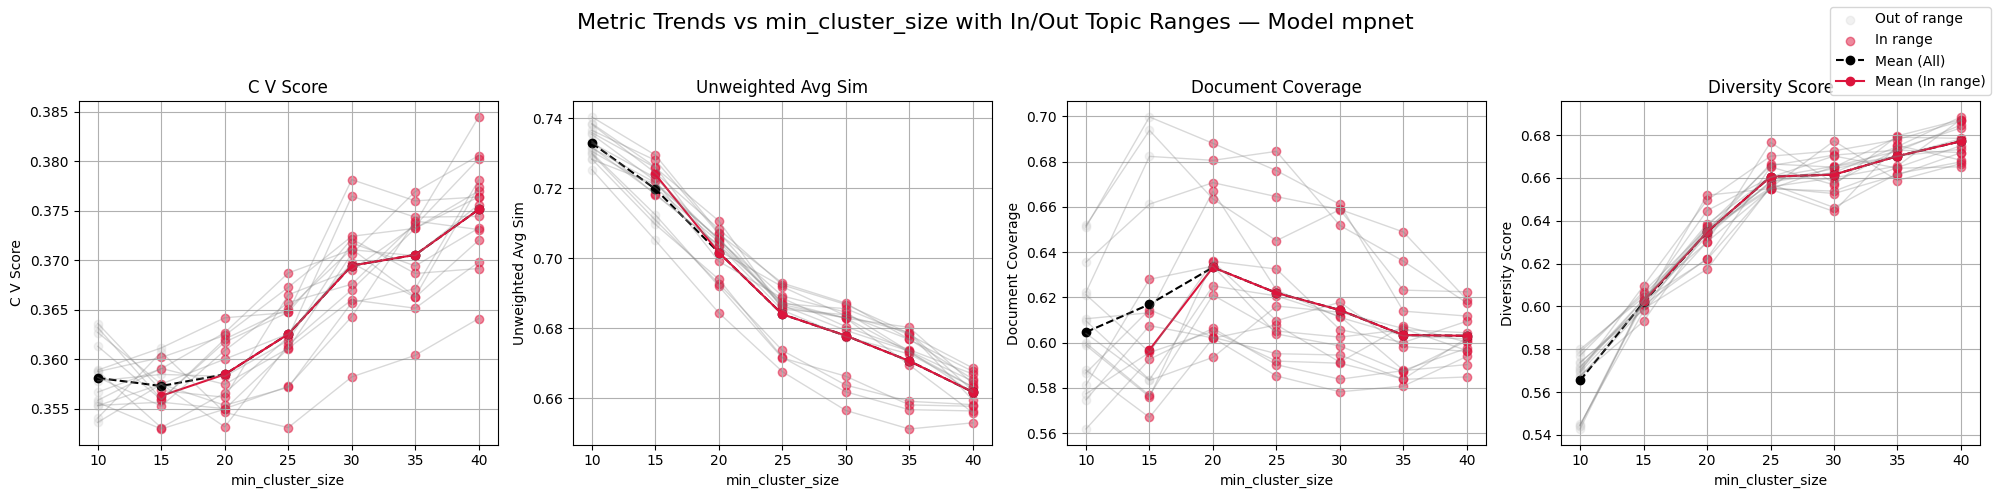

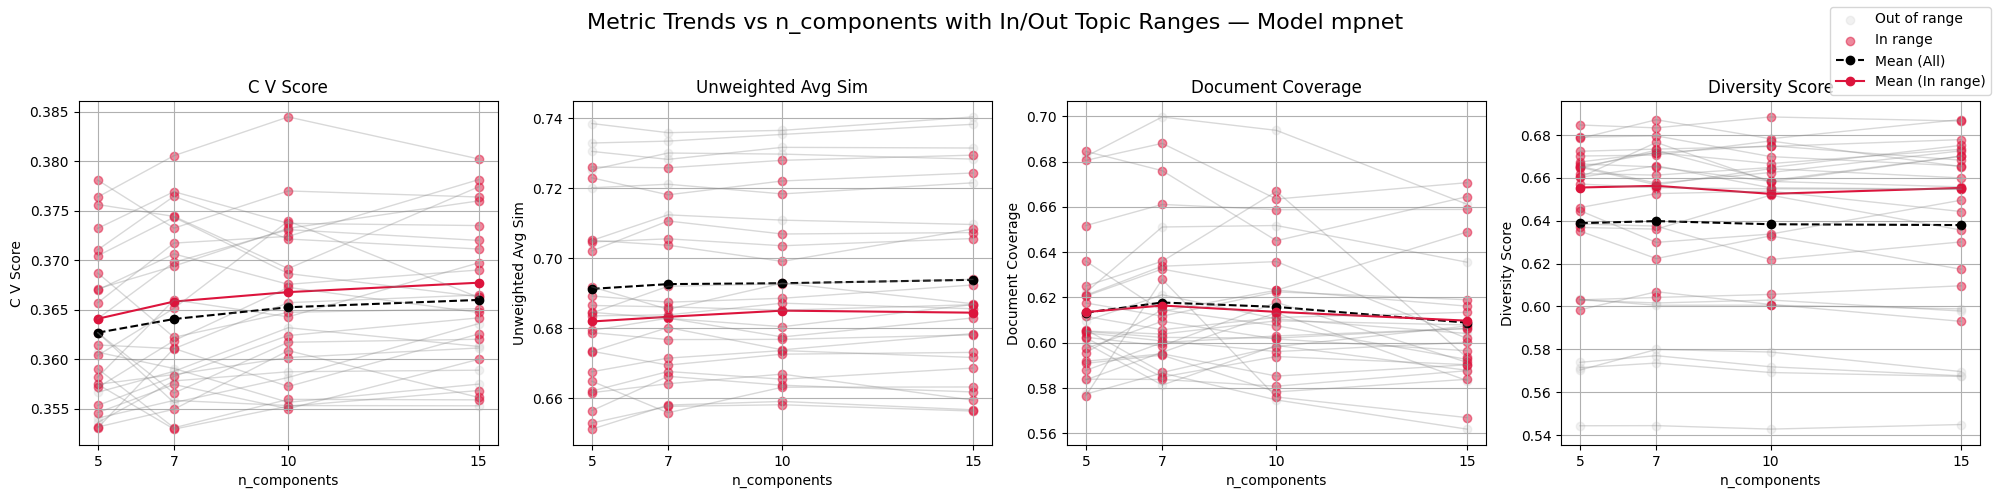

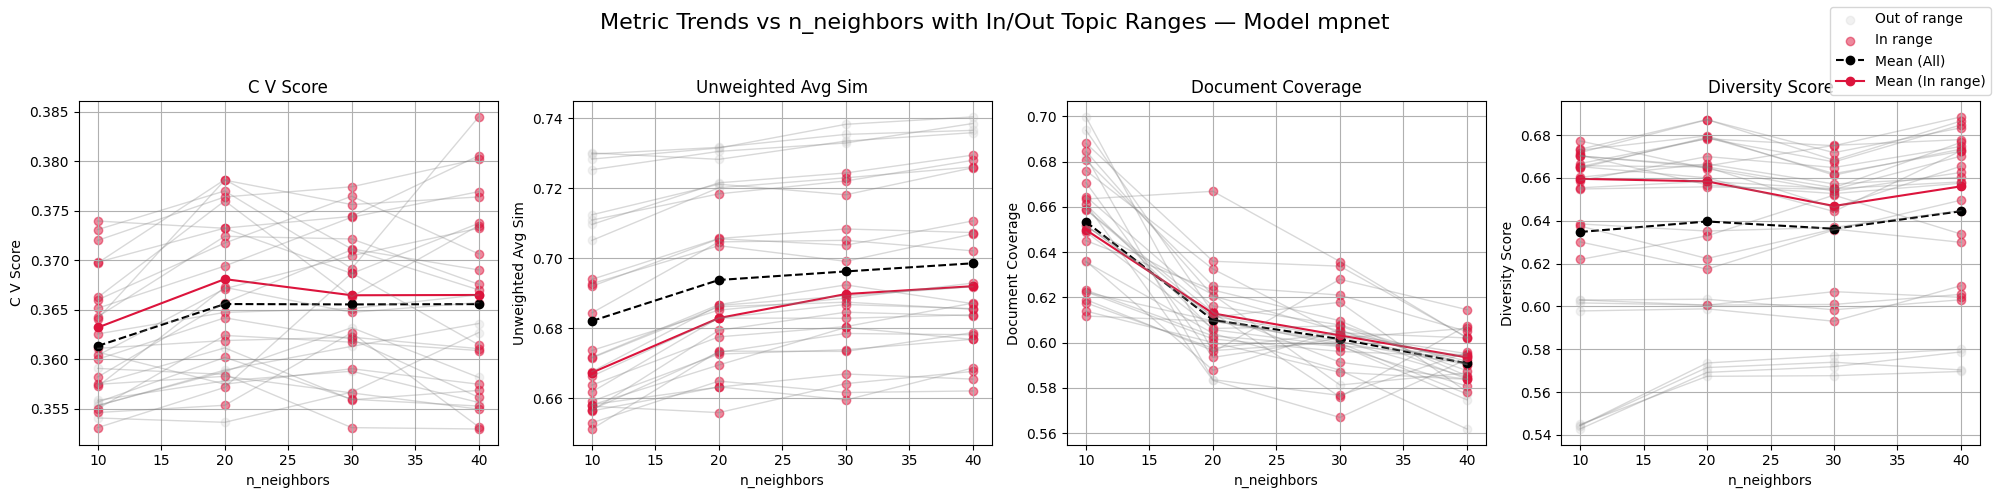

In [8]:
for parameter in parameters:
    visualize_trends_permodel(model_name="mpnet", parameter_to_plot=parameter, main_color=model_colors["mpnet"])

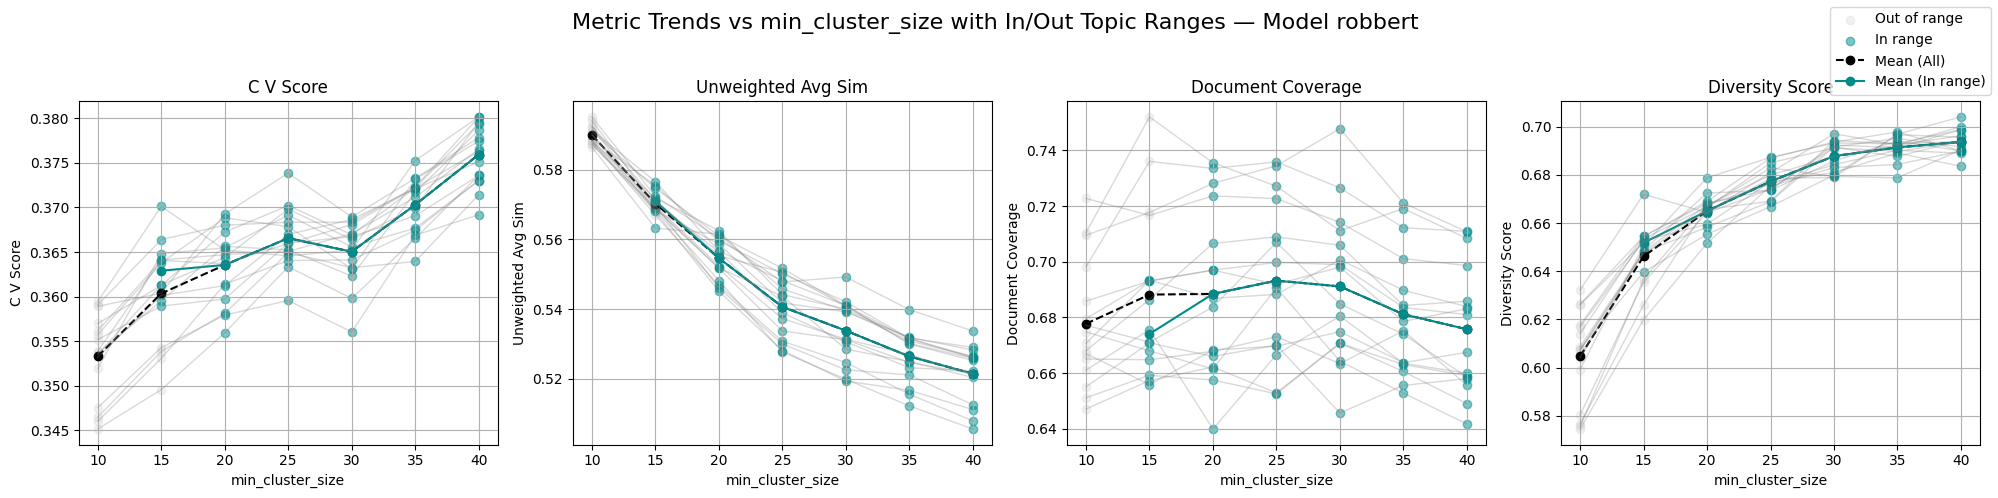

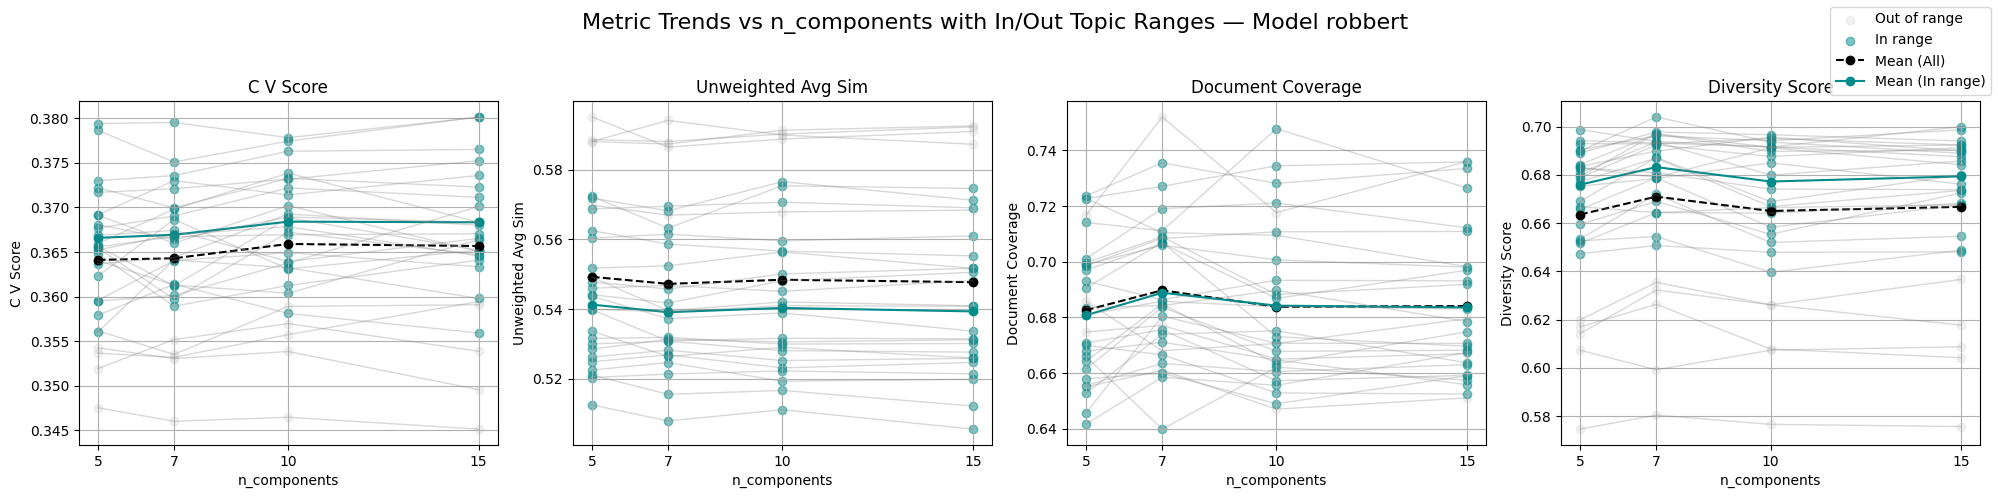

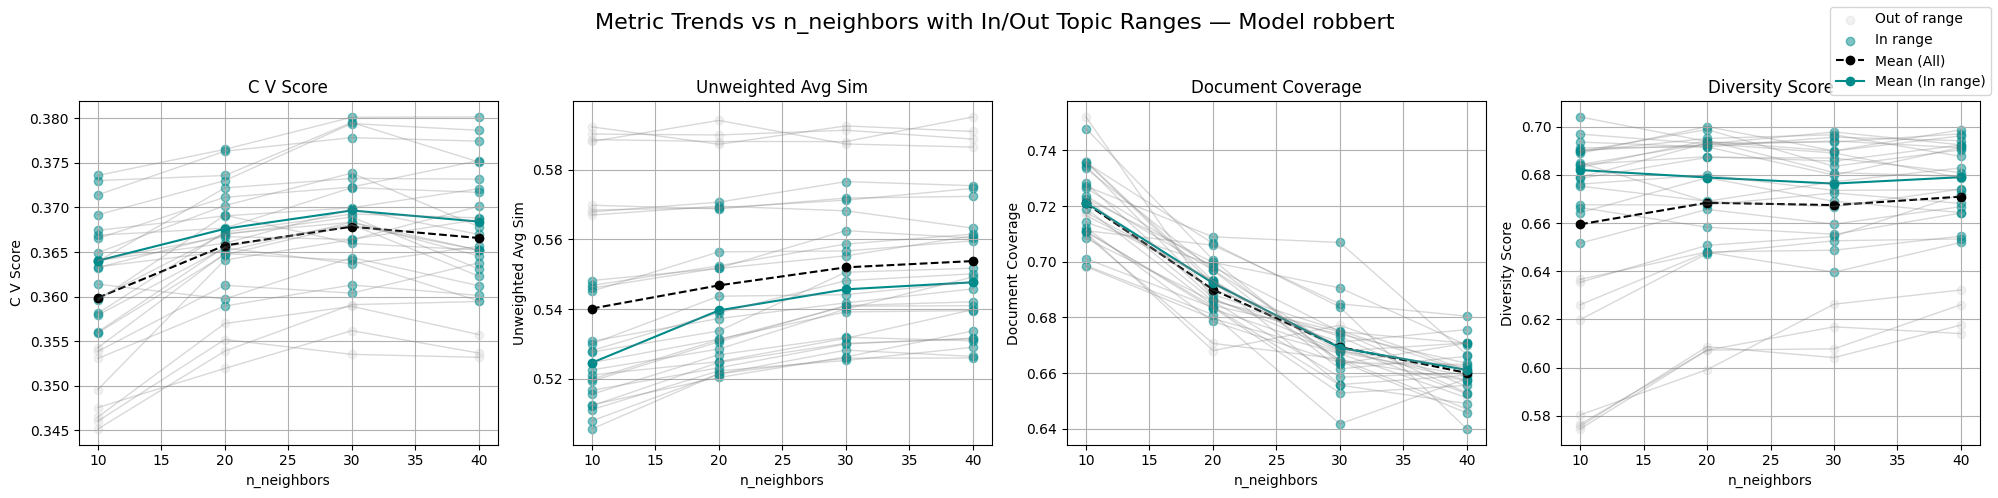

In [9]:
for parameter in parameters:
    visualize_trends_permodel(model_name="robbert", parameter_to_plot=parameter, main_color=model_colors["robbert"])

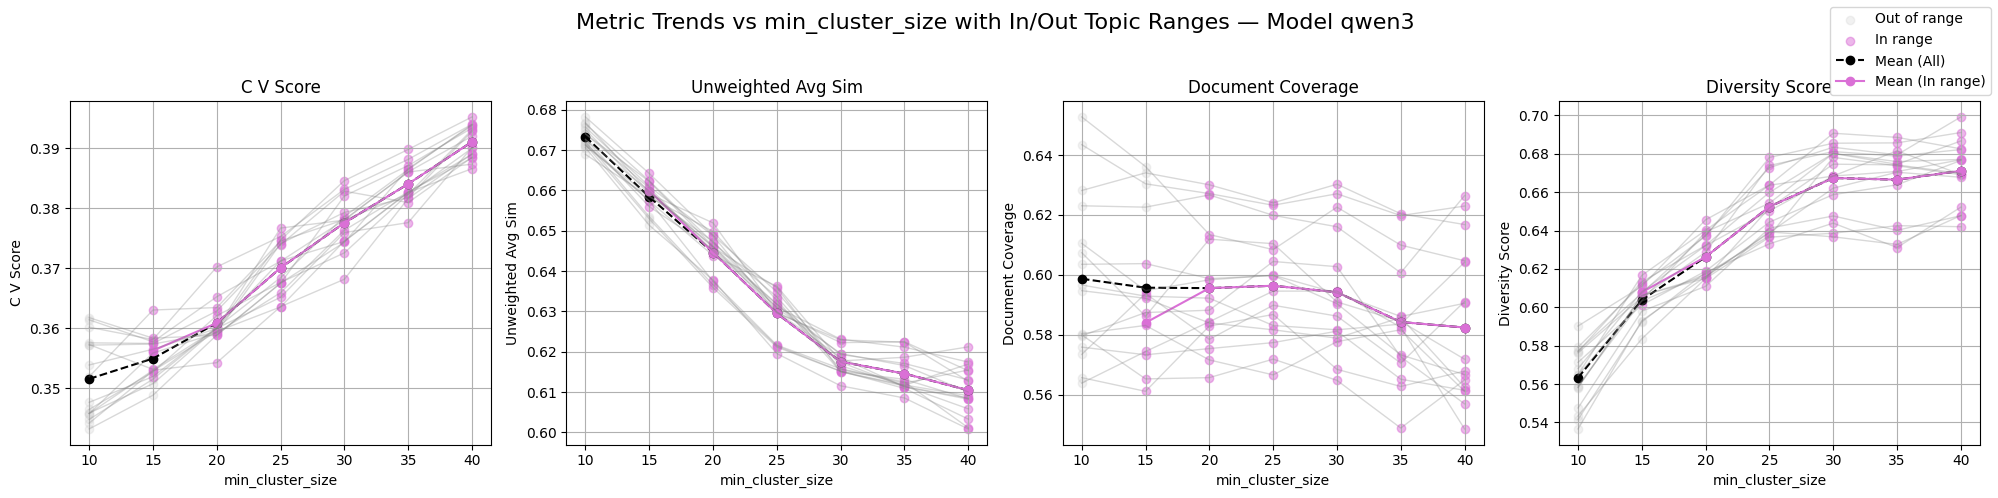

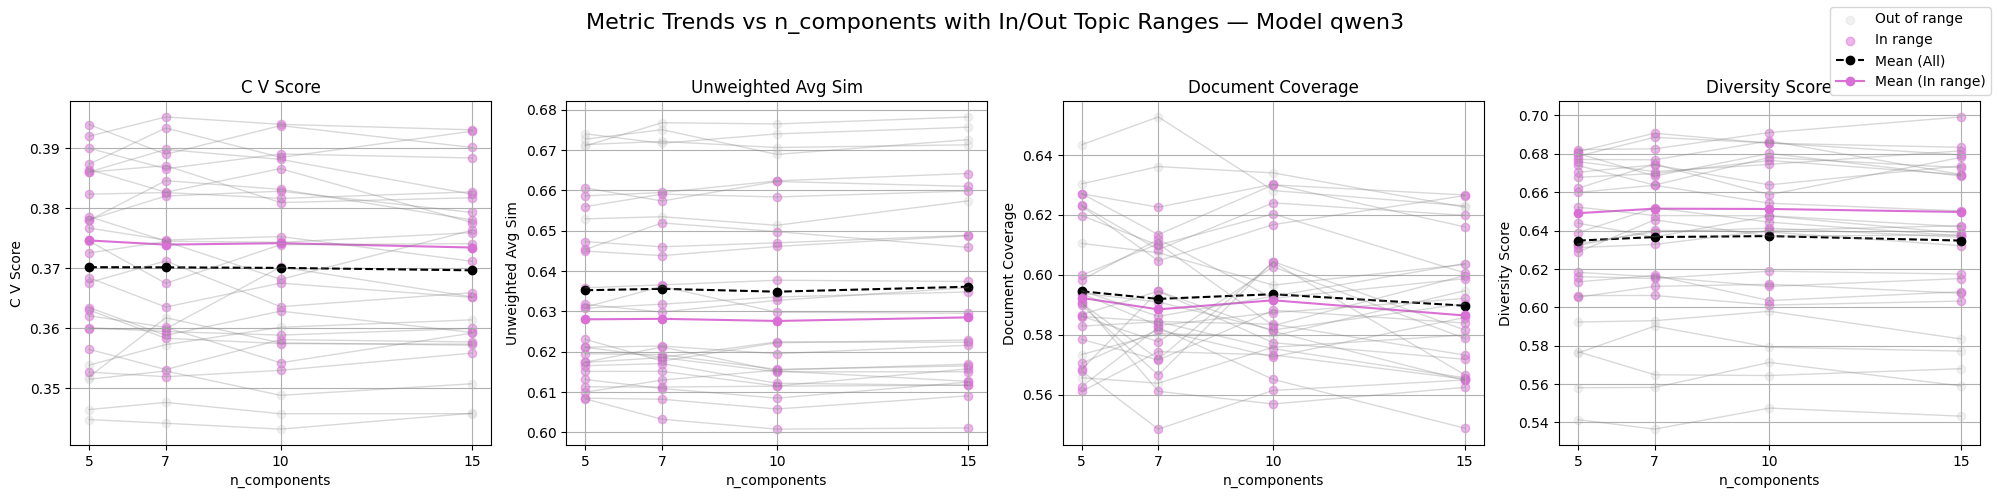

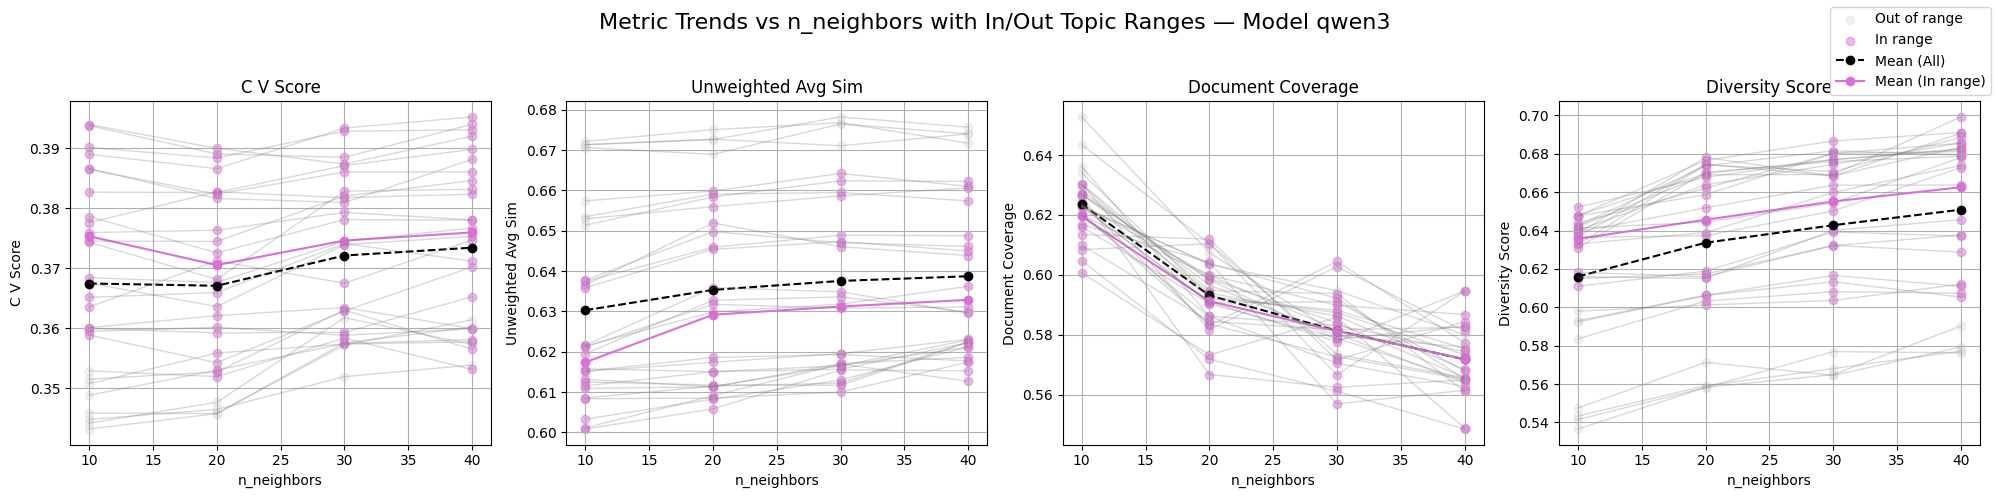

In [10]:
for parameter in parameters:
    visualize_trends_permodel(model_name="qwen3", parameter_to_plot=parameter, main_color=model_colors["qwen3"])

In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

def plot_inrange_mean_trends_all_models(df, models, parameter_to_plot, model_colors):
    parameters = ["min_cluster_size", "n_components", "n_neighbors"]
    metrics = [
        "c_v_score",
        "diversity_score",
        "document_coverage"
    ]

    min_topics, max_topics = 50, 350

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5), sharex=False)
    axes = axes.flatten()

    for model_name in models:
        df_model = df[df["model_name"] == model_name].copy()

        # Normalize metrics for fair comparison
        scaler = MinMaxScaler()
        df_model[metrics] = scaler.fit_transform(df_model[metrics])

        # All data
        df_all = df_model

        # In-range data
        in_range = (df_model["number_of_topics"] >= min_topics) & (df_model["number_of_topics"] <= max_topics)
        df_inrange = df_model[in_range]

        for i, metric in enumerate(metrics):
            # Plot full-data trends (solid line)
            mean_all = df_all.groupby(parameter_to_plot)[metric].mean()
            axes[i].plot(
                mean_all.index,
                mean_all.values,
                marker="o",
                linestyle="--",
                label=f"{model_name} (all)",
                color=model_colors[model_name],
                alpha=0.4
            )

            # Plot in-range trends (dotted line)
            mean_in = df_inrange.groupby(parameter_to_plot)[metric].mean()
            axes[i].plot(
                mean_in.index,
                mean_in.values,
                marker="o",
                label=f"{model_name} (in-range)",
                color=model_colors[model_name],
                alpha=1
            )

    # Formatting
    for ax, metric in zip(axes, metrics):
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel("Normalized Score")
        ax.set_xlabel(parameter_to_plot)
        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.legend()
        if parameter_to_plot == "n_components":
            unique_vals = sorted(df[parameter_to_plot].unique())
            ax.set_xticks(unique_vals)

    fig.suptitle(f"Mean Trends by Model — Parameter: {parameter_to_plot}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


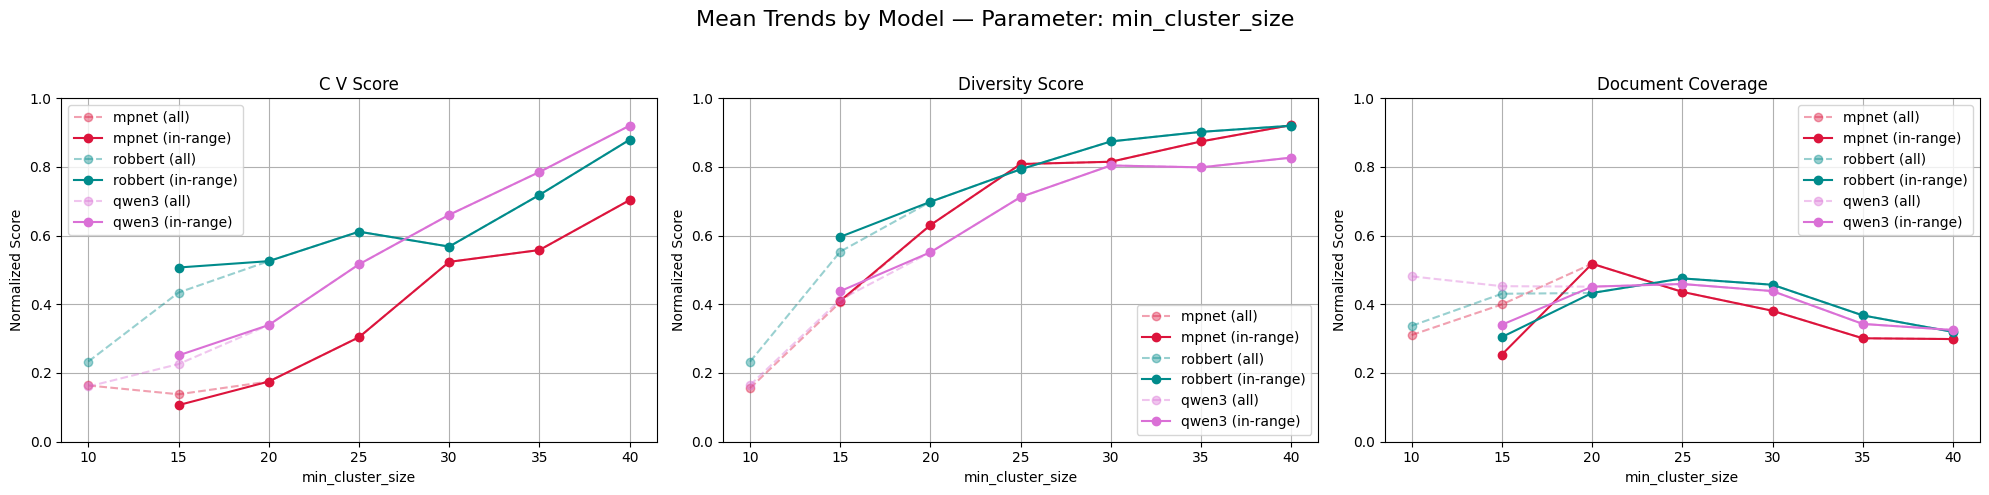

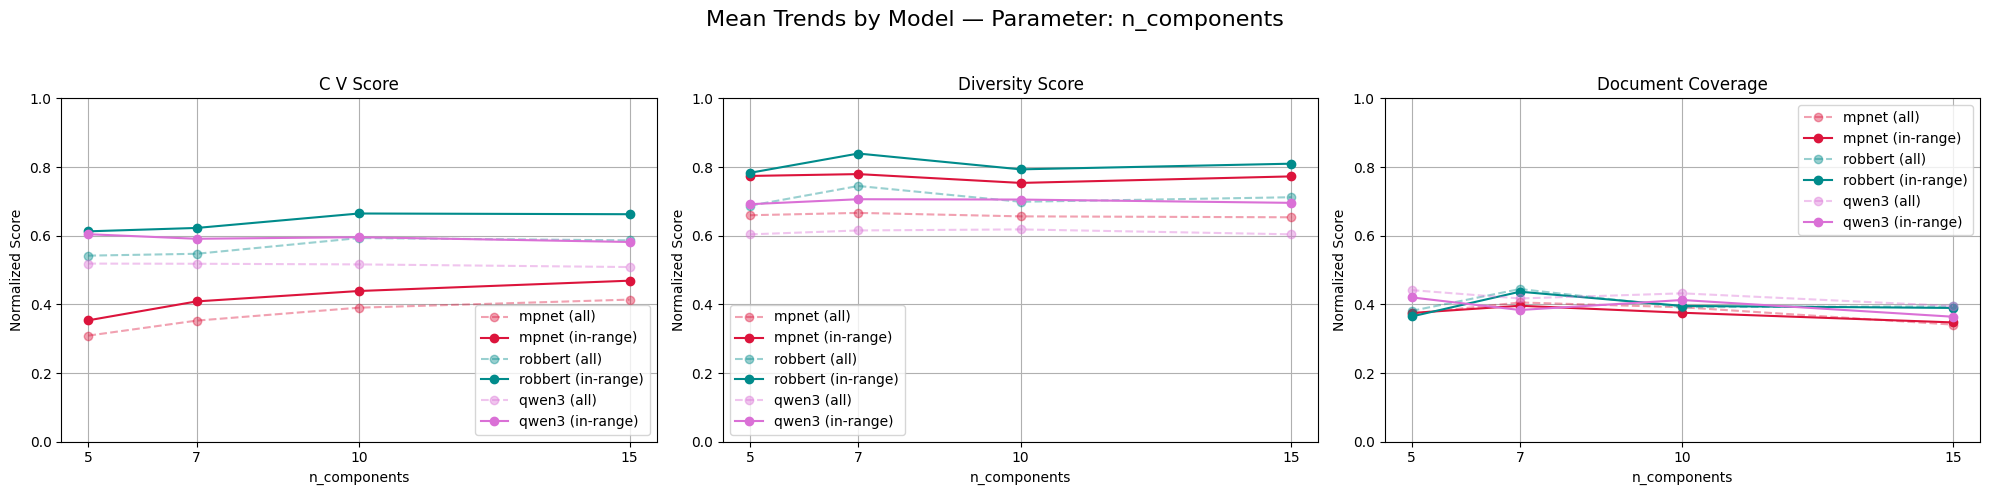

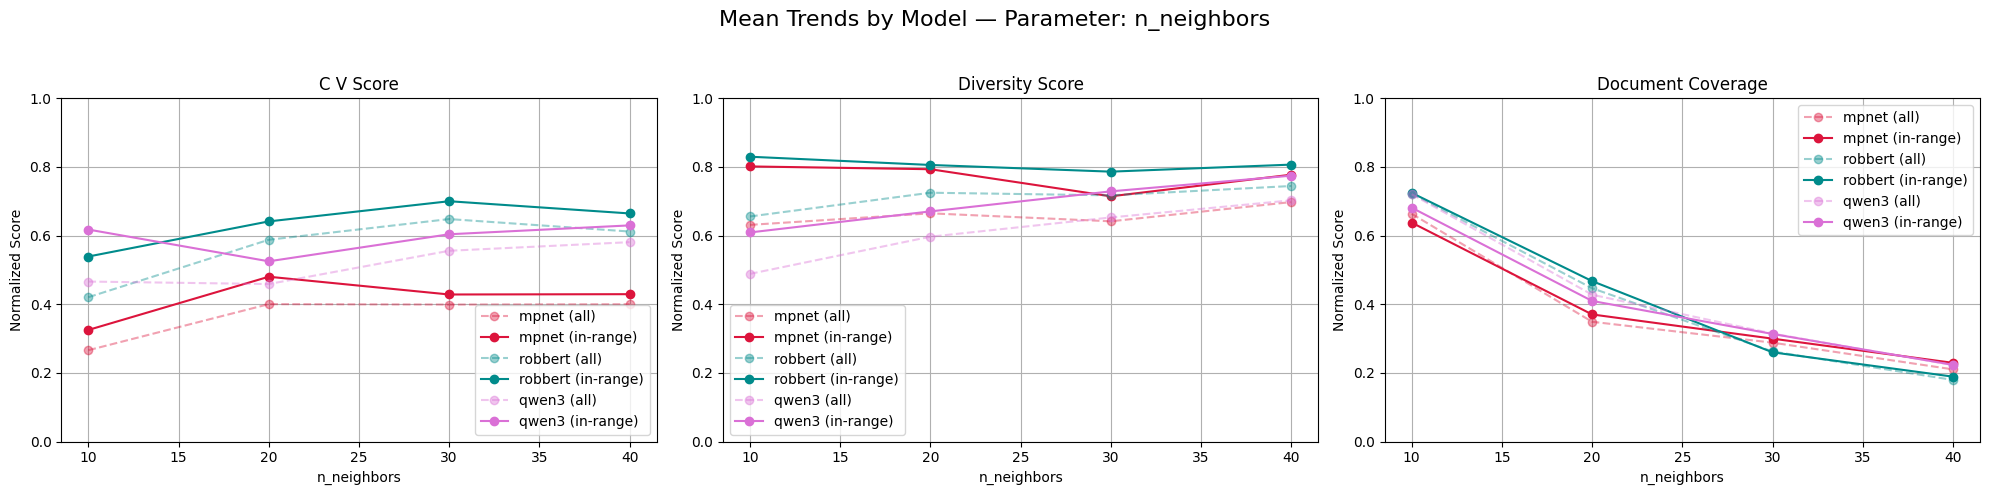

In [23]:
for parameter_to_plot in parameters:
    plot_inrange_mean_trends_all_models(df, models, parameter_to_plot=parameter_to_plot, model_colors=model_colors)

### Find the best combo of each model

In [ ]:
df.columns

In [5]:
df_inrange = df[df["number_of_topics"].between(50, 350)]

In [6]:
# print the mean and standard deviation for every metric of every model 
for metric in ["c_v_score", "diversity_score", "document_coverage"]:
    for model in ["mpnet", "robbert", "qwen3"]:
        mean_value = df_inrange[df_inrange["model_name"] == model][metric].mean()
        std_value = df_inrange[df_inrange["model_name"] == model][metric].std()
        print(f"Model: {model}, Metric: {metric}, Mean: {mean_value:.4f}, Std: {std_value:.4f}")

Model: mpnet, Metric: c_v_score, Mean: 0.3661, Std: 0.0078
Model: robbert, Metric: c_v_score, Mean: 0.3676, Std: 0.0056
Model: qwen3, Metric: c_v_score, Mean: 0.3740, Std: 0.0126
Model: mpnet, Metric: diversity_score, Mean: 0.6549, Std: 0.0236
Model: robbert, Metric: diversity_score, Mean: 0.6789, Std: 0.0157
Model: qwen3, Metric: diversity_score, Mean: 0.6504, Std: 0.0270
Model: mpnet, Metric: document_coverage, Mean: 0.6133, Std: 0.0272
Model: robbert, Metric: document_coverage, Mean: 0.6844, Std: 0.0253
Model: qwen3, Metric: document_coverage, Mean: 0.5897, Std: 0.0206


In [24]:
# print the mean and standard deviation for every metric of every model 
for metric in ["c_v_score", "diversity_score", "document_coverage"]:
    for model in ["mpnet", "robbert", "qwen3"]:
        mean_value = df[df["model_name"] == model][metric].mean()
        std_value = df[df["model_name"] == model][metric].std()
        print(f"Model: {model}, Metric: {metric}, Mean: {mean_value:.4f}, Std: {std_value:.4f}")

Model: mpnet, Metric: c_v_score, Mean: 0.3645, Std: 0.0077
Model: robbert, Metric: c_v_score, Mean: 0.3650, Std: 0.0077
Model: qwen3, Metric: c_v_score, Mean: 0.3700, Std: 0.0146
Model: mpnet, Metric: diversity_score, Mean: 0.6388, Std: 0.0392
Model: robbert, Metric: diversity_score, Mean: 0.6666, Std: 0.0313
Model: qwen3, Metric: diversity_score, Mean: 0.6358, Std: 0.0404
Model: mpnet, Metric: document_coverage, Mean: 0.6139, Std: 0.0300
Model: robbert, Metric: document_coverage, Mean: 0.6851, Std: 0.0261
Model: qwen3, Metric: document_coverage, Mean: 0.5924, Std: 0.0227


In [46]:
# rank by "diversity_score" followed by "document_coverage" in the df 
df_sorted = df_inrange.sort_values(by="diversity_score", ascending=[False])
# filter out document_coverage < 0.6
df_sorted = df_sorted[df_sorted["document_coverage"] >= 0.63]
df_sorted[df_sorted["model_name"] == "qwen3"]

,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
232,qwen3,"(30, 10, 10)",30,10,10,0.647596,0.374300,0.585181,0.611520,0.630244,208
200,qwen3,"(20, 10, 10)",20,10,10,0.610922,0.358838,0.597739,0.637728,0.630049,293


In [8]:
# best configuration for each model are:
config_mpnet = (30, 10, 10)
config_robbert = (40, 7, 10)
config_qwen3 = (30, 10, 10)

In [9]:
# get topic info for each model of their best configuration

import pandas as pd
# read the sentence data 
data = pd.read_excel("..\\..\\data\\sentence_data_for_analysis.xlsx", index_col=0)
sentences = data["sentence"].to_list()

In [21]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('..\\..\\data\\stopwords-nl.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

In [11]:
#%pip install umap-learn hdbscan 

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Shared settings with multiple representation models
bertopic_settings = {
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": False
    #"representation_model": {
        #"Default": "default",  # This uses the default c-TF-IDF representation
        #"KeyBERTInspired": KeyBERTInspired()
    #}
}


c:\Users\p70092940\OneDrive - Maastricht University\Desktop\Projects\MyIBDcoach-NLP\mijnidbcoachnlp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
from bertopic import BERTopic
import numpy as np
# function to calculate coverage
def get_coverage(topic_model):
    """Calculate the proportion of documents assigned to valid topics (topic != -1)."""
    topics = topic_model.topics_
    print(f"Number of documents: {len(topics)}")
    valid_topic_count = sum(1 for topic in topics if topic != -1)
    print(f"Valid topics: {valid_topic_count}")
    print(f"Outliers: {len(topics) - valid_topic_count}")
    return valid_topic_count / len(topics)

# fit the best mpnet model with the best parameters
# access the three params
min_cluster_size, n_components, n_neighbors = config_mpnet
embeddings = np.load("..\\..\\data\\embeddings_st_mpnet_v2_sentence_placeholder.npy")
#embedding_model = SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")
# initialize a topic model with the basic setting
topic_model_mpnet = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model_mpnet.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model_mpnet.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: mpnet at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics_mpnet, probs_mpnet = topic_model_mpnet.fit_transform(sentences, embeddings)
coverage_mpnet = get_coverage(topic_model_mpnet)
print(f"Coverage of the model: {coverage_mpnet:.4f}")



Tuning model: mpnet at param combination: min_cluster_size = 30, n_components = 10, n_neighbors = 10
Number of documents: 41119
Valid topics: 26083
Outliers: 15036
Coverage of the model: 0.6343


In [13]:
from bertopic import BERTopic
import numpy as np
#from sentence_transformers import SentenceTransformer

# fit the best robbert model with the best parameters
# access the three params
min_cluster_size, n_components, n_neighbors = config_robbert
embeddings = np.load("..\\..\\data\\embeddings_st_robbert2022_sentence_placeholder.npy")
#embedding_model = SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")
# initialize a topic model with the basic setting
topic_model_robbert = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model_robbert.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model_robbert.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: robbert at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics_robbert, probs_robbert = topic_model_robbert.fit_transform(sentences, embeddings)

Tuning model: robbert at param combination: min_cluster_size = 40, n_components = 7, n_neighbors = 10


In [47]:
from bertopic import BERTopic
import numpy as np
#from sentence_transformers import SentenceTransformer

# fit the best robbert model with the best parameters
# access the three params
min_cluster_size, n_components, n_neighbors = config_qwen3
embeddings = np.load("..\\..\\data\\embeddings_st_robbert2022_sentence_placeholder.npy")
#embedding_model = SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")
# initialize a topic model with the basic setting
topic_model_qwen3 = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model_qwen3.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model_qwen3.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: qwen3 at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics_qwen3, probs_qwen3 = topic_model_qwen3.fit_transform(sentences, embeddings)
coverage_qwen3 = get_coverage(topic_model_qwen3)
print(f"Coverage of the model: {coverage_qwen3:.4f}")

Tuning model: qwen3 at param combination: min_cluster_size = 30, n_components = 10, n_neighbors = 10
Number of documents: 41119
Valid topics: 29644
Outliers: 11475
Coverage of the model: 0.7209


In [ ]:
topic_info_mpnet = topic_model_mpnet.get_topic_info()
topic_info_robbert = topic_model_robbert.get_topic_info()
topic_info_qwen3 = topic_model_qwen3.get_topic_info()

In [44]:
topic_info_mpnet 

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15036,-1_persoon_afspraak_graag_buikpijn,"[persoon, afspraak, graag, buikpijn, apotheek,...","[Hallo, Ik zou willen vragen of de uitslag va..."
1,0,2886,0_bloed_prikken_bloedprikken_ontlasting,"[bloed, prikken, bloedprikken, ontlasting, lat...","[Hallo, Ik heb 2 april weer bloed laten prikke..."
2,1,1053,1_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, cont...","[Ik ben net bij de huisarts geweest., De huisa..."
3,2,597,2_medicatie_medicijn_medicijnen_bijwerkingen,"[medicatie, medicijn, medicijnen, bijwerkingen...",[Nu vraag ik me af of het met de medicatie te ...
4,3,523,3_toilet_vaker_rennen_keer,"[toilet, vaker, rennen, keer, toiletbezoek, da...","[Ga zeker 20x per dag naar toilet., Kan wel ie..."
...,...,...,...,...,...
185,184,31,184_datum_datums_tijdstip_verschillen,"[datum, datums, tijdstip, verschillen, getalle...",[Er staat [DATUM] of maakt deze datum niet hee...
186,185,31,185_recept_vergeten_picoprep_voorbereiding,"[recept, vergeten, picoprep, voorbereiding, aa...","[Maar er was geen recept., We zijn echter verg..."
187,186,31,186_hoor_graag__,"[hoor, graag, , , , , , , , ]","[Ik hoor het graag!, Ik hoor het graag!, Ik ho..."
188,187,30,187_leverwaarden_leverwaardes_lever_verhoogde,"[leverwaarden, leverwaardes, lever, verhoogde,...","[Beste [PERSOON] en [PERSOON], Ik zou graag ..."


In [45]:
(len(sentences) - 15036)/len(sentences)

0.6343296286388288

In [28]:
topic_info_mpnet

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15036,-1_persoon_afspraak_graag_buikpijn,"[persoon, afspraak, graag, buikpijn, apotheek,...","[Hallo, Ik zou willen vragen of de uitslag va..."
1,0,2886,0_bloed_prikken_bloedprikken_ontlasting,"[bloed, prikken, bloedprikken, ontlasting, lat...","[Hallo, Ik heb 2 april weer bloed laten prikke..."
2,1,1053,1_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, cont...","[Ik ben net bij de huisarts geweest., De huisa..."
3,2,597,2_medicatie_medicijn_medicijnen_bijwerkingen,"[medicatie, medicijn, medicijnen, bijwerkingen...",[Nu vraag ik me af of het met de medicatie te ...
4,3,523,3_toilet_vaker_rennen_keer,"[toilet, vaker, rennen, keer, toiletbezoek, da...","[Ga zeker 20x per dag naar toilet., Kan wel ie..."
...,...,...,...,...,...
185,184,31,184_datum_datums_tijdstip_verschillen,"[datum, datums, tijdstip, verschillen, getalle...",[Er staat [DATUM] of maakt deze datum niet hee...
186,185,31,185_recept_vergeten_picoprep_voorbereiding,"[recept, vergeten, picoprep, voorbereiding, aa...","[Maar er was geen recept., We zijn echter verg..."
187,186,31,186_hoor_graag__,"[hoor, graag, , , , , , , , ]","[Ik hoor het graag!, Ik hoor het graag!, Ik ho..."
188,187,30,187_leverwaarden_leverwaardes_lever_verhoogde,"[leverwaarden, leverwaardes, lever, verhoogde,...","[Beste [PERSOON] en [PERSOON], Ik zou graag ..."


In [17]:
import pandas as pd

def get_top_topics_with_outlier(df, model_name):
    # Get outlier topic (-1), if it exists
    outlier = df[df["Topic"] == -1]

    # Get top 15 topics (excluding outlier)
    top_topics = df[df["Topic"] != -1].nlargest(15, 'Count')

    # Combine top topics and outlier
    selected = pd.concat([top_topics, outlier], axis=0).reset_index(drop=True)

    # Keep topic ID, representation, and count
    return selected[["Representation", "Count"]].rename(
        columns={
            "Representation": f"{model_name}_Representation",
            "Count": f"{model_name}_Count"
        }
    )

# Apply function to each topic_info DataFrame
df_mpnet = get_top_topics_with_outlier(topic_info_mpnet, "MPNet")
df_robbert = get_top_topics_with_outlier(topic_info_robbert, "RobBERT")
df_qwen3 = get_top_topics_with_outlier(topic_info_qwen3, "Qwen3")

# Combine side-by-side
comparison_df = pd.concat([df_mpnet, df_robbert, df_qwen3], axis=1)
# add a column for "Topic" fron 1 to 15 and the last one is -1
comparison_df["Topic"] = list(range(1, 16)) + [-1]

# View result
comparison_df.head(16)  # Should show 16 rows: 15 top + 1 outlier per model


,MPNet_Representation,MPNet_Count,RobBERT_Representation,RobBERT_Count,Qwen3_Representation,Qwen3_Count,Topic
0,"[bloed, prikken, bloedprikken, ontlasting, lat...",2886,"[ontlasting, ingeleverd, inleveren, bloed, pri...",1437,"[ontlasting, ingeleverd, inleveren, bloed, pri...",1438,1
1,"[huisarts, arts, dokter, mdl, ziekenhuis, cont...",1053,"[apotheek, recept, locatie, sturen, faxen, nie...",864,"[apotheek, recept, locatie, sturen, nieuw, fax...",955,2
2,"[medicatie, medicijn, medicijnen, bijwerkingen...",597,"[mail, ontvangen, post, gestuurd, bericht, stu...",705,"[mail, ontvangen, ophalen, post, verstuurd, ge...",733,3
3,"[toilet, vaker, rennen, keer, toiletbezoek, da...",523,"[medicatie, medicijnen, medicijn, bijwerkingen...",667,"[afspraak, staan, afspraken, verzetten, planne...",696,4
4,"[pijn, gewrichten, benen, rug, pijnlijk, hande...",509,"[afspraak, staan, verzetten, gepland, afsprake...",660,"[humira, spuit, spuiten, zetten, injectie, ges...",600,5
5,"[test, thuistest, testen, gedaan, zelftest, th...",508,"[huisarts, dokter, arts, contact, huisartsenpo...",607,"[huisarts, dokter, arts, contact, huisartsenpo...",539,6
6,"[calprotectine, calpro, thuistest, waarde, tes...",491,"[bericht, bedankt, fijn, hoi, dank, prima, per...",600,"[prikken, bloed, bloedprikken, laten, geprikt,...",523,7
7,"[humira, spuit, spuiten, zetten, injectie, ges...",429,"[humira, spuit, spuiten, zetten, injectie, geb...",595,"[bloeduitslagen, bloeduitslag, bloedwaarden, b...",492,8
8,"[apotheek, recept, sturen, locatie, ophalen, n...",405,"[prikken, bloed, laten, bloedprikken, geprikt,...",540,"[infuus, entyvio, infuuscentrum, volgende, gep...",444,9
9,"[tabletten, daags, prednisolon, prednison, dag...",399,"[infuus, remsima, remicade, volgende, entyvio,...",494,"[ontlasting, dunne, dun, vaste, aandrang, wate...",427,10


In [48]:
comparison_df


,MPNet_Representation,MPNet_Count,RobBERT_Representation,RobBERT_Count,Qwen3_Representation,Qwen3_Count
0,"[bloed, prikken, ontlasting, laten, bloedprikken, bloeduitslagen, ingeleverd, geprikt, inleveren, slijm]",2887,"[ontlasting, ingeleverd, inleveren, bloed, prikken, uitslag, laten, leveren, bloedprikken, buisje]",1437,"[ontlasting, ingeleverd, inleveren, bloed, prikken, leveren, uitslag, laten, buisje, bloedprikken]",1424
1,"[huisarts, arts, dokter, mdl, ziekenhuis, verpleegkundige, contact, afspraak, medische, bespreken]",1058,"[apotheek, recept, locatie, sturen, faxen, nieuw, ophalen, doorsturen, gestuurd, ontvangen]",864,"[bellen, bereikbaar, gebeld, telefonisch, belafspraak, contact, telefoon, nummer, telefoonnummer, telefonische]",1079
2,"[apotheek, locatie, recept, sturen, nieuw, ophalen, zorginstelling, recepten, ziekenhuis, doorsturen]",682,"[mail, ontvangen, post, gestuurd, bericht, sturen, ophalen, verstuurd, email, opsturen]",705,"[apotheek, recept, locatie, sturen, faxen, nieuw, recepten, doorsturen, herhaalrecept, ophalen]",884
3,"[medicatie, medicijnen, medicijn, zetpillen, bijwerkingen, stoppen, gebruik, bijwerking, medicijngebruik, narcose]",665,"[medicatie, medicijnen, medicijn, bijwerkingen, stoppen, medicijngebruik, gebruik, starten, kuur, gebruiken]",667,"[humira, spuit, spuiten, zetten, injectie, gespoten, gebruik, spiegel, prik, antistoffen]",599
4,"[calprotectine, calpro, waarde, thuistest, test, uitslag, bekend, gedaan, meten, gemeten]",494,"[afspraak, staan, verzetten, gepland, afspraken, plannen, maandag, nieuwe, inplannen, ingepland]",660,"[prikken, bloed, bloedprikken, laten, geprikt, bloedgeprikt, gaan, ziekenhuis, voren, maandag]",551
5,"[toilet, vaker, keer, dag, rennen, toiletbezoek, gaan, gemiddeld, slijm, toiletbezoeken]",493,"[huisarts, dokter, arts, contact, huisartsenpost, medische, doktersverklaring, ggd, afspraak, behandelend]",607,"[afspraak, staan, verzetten, afspraken, gepland, plannen, agenda, nieuwe, inplannen, maandag]",532
6,"[pijn, gewrichten, benen, pijnlijk, handen, rug, last, linker, rugpijn, armen]",479,"[bericht, bedankt, fijn, hoi, dank, prima, persoon, dankjewel, info, goedemiddag]",600,"[huisarts, dokter, arts, contact, afspraak, behandelend, ggd, bespreken, huisartsenpost, hiervoor]",530
7,"[test, thuistest, gedaan, testen, zelftest, thuis, thuistesten, ontlastingtest, nieuwe, uitvoeren]",473,"[humira, spuit, spuiten, zetten, injectie, gebruik, gespoten, spiegel, prik, antistoffen]",595,"[mogelijk, nakijken, geregeld, klopt, oorzaak, probleem, bedoeling, optie, reden, mogelijkheden]",521
8,"[humira, spuit, spuiten, zetten, injectie, gebruik, gespoten, prik, injecties, weken]",438,"[prikken, bloed, laten, bloedprikken, geprikt, gaan, bloedgeprikt, ziekenhuis, voren, week]",540,"[test, thuistest, testen, gedaan, zelftest, thuistesten, getest, positief, negatief, thuis]",478
9,"[tabletten, daags, prednisolon, dag, prednison, tablet, gebruik, slik, mesalazine, afbouwen]",423,"[infuus, remsima, remicade, volgende, entyvio, infuuscentrum, gepland, krijg, woensdag, weken]",494,"[uitslag, resultaten, hiervan, bekend, daarvan, resultaat, benieuwd, weten, uitkomst, toevallig]",421


In [ ]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
hierarchical_topics[hierarchical_topics["Distance"] <= 0.6]

In [ ]:
from bertopic import BERTopic
import numpy as np
#from sentence_transformers import SentenceTransformer

# fit the best robbert model with the best parameters
# access the three params
min_cluster_size, n_components, n_neighbors = (40, 15, 40)
embeddings = np.load("..\\..\\embeddings_qwen3.npy")
# initialize a topic model with the basic setting
topic_model_qwen3 = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model_qwen3.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model_qwen3.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: {name} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics_qwen3, probs_qwen3 = topic_model_qwen3.fit_transform(sentences, embeddings)

In [ ]:
topic_model_qwen3.get_topic_info()[-20:]

In [ ]:
from bertopic import BERTopic
import numpy as np
#from sentence_transformers import SentenceTransformer

# fit the best robbert model with the best parameters
# access the three params
min_cluster_size, n_components, n_neighbors = (40, 10, 40)
embeddings = np.load("..\\..\\embeddings_st_mpnet_v2_sentence_placeholder.npy")
# initialize a topic model with the basic setting
topic_model_mpnet = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model_mpnet.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model_mpnet.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: mpnet at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics_mpnet, topics_mpnet = topic_model_mpnet.fit_transform(sentences, embeddings)

In [ ]:
topic_model_mpnet.get_topic_info()[:15]